In [1]:
# Packages to load
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import zipfile
import matplotlib.pyplot as plt
import os
import glob

import urllib.request
from scipy.ndimage import gaussian_filter, minimum_filter
from matplotlib.colors import hsv_to_rgb

In [2]:
!pip install -q py4DSTEM

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 760.0 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 729.1/729.1 kB 4.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 MB 25.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.8/272.8 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.2/293.2 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 35.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 369.9/369.9 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 39.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.0/244.0 kB 12.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the followin

# Data sourcing,Reading,Inspection & Virtualization; EDA

!rm -rf /kaggle/working/*

#Finding the file in /kaggle/inpu....
input_files = glob.glob("/kaggle/input/**/*.npz", recursive=True)
if input_files:
    file_path = input_files[0]
else:
    !kaggle datasets download -d mdramjanali/prefiltered-4dstem-au-nanoparticle-liquid-cell-tem -p /kaggle/working/ --unzip
    file_path = glob.glob("/kaggle/working/*.npz")[0]
    
print("Using dataset file:", file_path)

!rm -rf /kaggle/working/*

In [3]:
!kaggle datasets download -d mdramjanali/prefiltered-4dstem-au-nanoparticle-liquid-cell-tem
!unzip -q prefiltered-4dstem-au-nanoparticle-liquid-cell-tem.zip -d /kaggle/working
!rm prefiltered-4dstem-au-nanoparticle-liquid-cell-tem.zip

Dataset URL: https://www.kaggle.com/datasets/mdramjanali/prefiltered-4dstem-au-nanoparticle-liquid-cell-tem
License(s): unknown
100%|██████████████████████████████████████| 6.87G/6.87G [05:41<00:00, 21.6MB/s]



In [4]:
npz_file = glob.glob("/kaggle/working/*.npz")[0]
print("File found at:", npz_file)

File found at: /kaggle/working/Prefiltered_4DSTEM_Au_nanoparticle_liquid_cell_TEM.npz


In [5]:
#Printing all folders, subfolders, and files
for path, subdirs, files in os.walk('/kaggle/working'):
    print(path, subdirs, files)

#Load dataset and print keys
data = np.load('/kaggle/working/Prefiltered_4DSTEM_Au_nanoparticle_liquid_cell_TEM.npz')
print("Keys:", data.files)

/kaggle/working ['.virtual_documents'] ['Prefiltered_4DSTEM_Au_nanoparticle_liquid_cell_TEM.npz']
/kaggle/working/.virtual_documents [] ['__notebook_source__.ipynb']
Keys: ['data']


In [6]:
archive = np.load(npz_file)
data = archive[archive.files[0]]
del archive

In [7]:
data.shape

(512, 512, 192, 192)

In [8]:
Ry, Rx, Ky, Kx = data.shape
print(f"Scan Grid: {Ry}x{Rx} | Detector: {Ky}x{Kx} | Dtype: {data.dtype}")

Scan Grid: 512x512 | Detector: 192x192 | Dtype: uint16


In [9]:
cy, cx = Ky // 2, Kx // 2
yy, xx = np.ogrid[:Ky, :Kx]
r = np.hypot(xx - cx, yy - cy)
print(r)

[[135.76450199 135.05924626 134.35773145 ... 133.66001646 134.35773145
  135.05924626]
 [135.05924626 134.35028843 133.64505228 ... 132.94359706 133.64505228
  134.35028843]
 [134.35773145 133.64505228 132.93607486 ... 132.23085873 132.93607486
  133.64505228]
 ...
 [133.66001646 132.94359706 132.23085873 ... 131.5218613  132.23085873
  132.94359706]
 [134.35773145 133.64505228 132.93607486 ... 132.23085873 132.93607486
  133.64505228]
 [135.05924626 134.35028843 133.64505228 ... 132.94359706 133.64505228
  134.35028843]]


In [10]:
mean_dp = data.mean(axis=(0,1))
mean_dp

array([[2.00985336, 1.92396545, 1.84233093, ..., 2.22320938, 2.33371353,
        2.84578705],
       [1.48020554, 1.45528793, 1.40539932, ..., 1.63759613, 1.77961349,
        2.55172348],
       [1.39673996, 1.31178665, 1.17435837, ..., 1.48417664, 1.71840668,
        2.36406326],
       ...,
       [1.5467453 , 1.39306259, 1.39178467, ..., 1.73348999, 1.81205368,
        2.54478073],
       [1.6556015 , 1.52891922, 1.53973007, ..., 1.81533051, 1.95433426,
        2.61979675],
       [2.1432724 , 2.1707077 , 2.11317062, ..., 2.48283005, 2.5266571 ,
        3.00310898]])

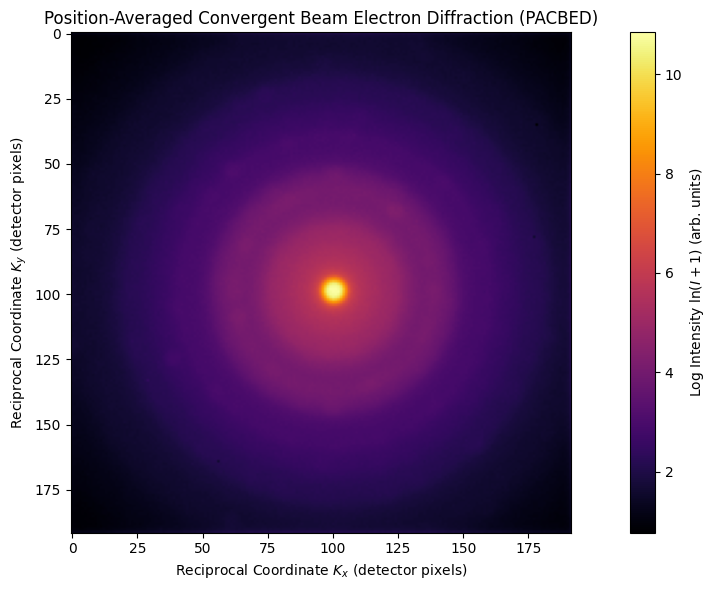

In [11]:
plt.figure(figsize=(12, 6))
plt.imshow(np.log1p(mean_dp), cmap="inferno")
plt.title("Position-Averaged Convergent Beam Electron Diffraction (PACBED)")
plt.xlabel("Reciprocal Coordinate $K_x$ (detector pixels)")
plt.ylabel("Reciprocal Coordinate $K_y$ (detector pixels)")
plt.colorbar(label=r"Log Intensity $\ln(I + 1)$ (arb. units)")
plt.tight_layout()
plt.savefig('mf.png')
plt.show()

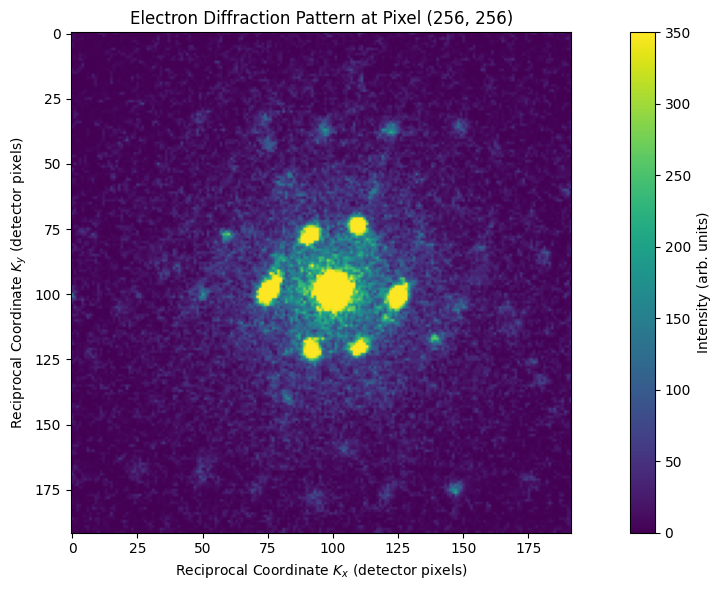

In [12]:
plt.figure(figsize=(12, 6))
plt.imshow(data[256,256], cmap="viridis", vmin=0, vmax=350)
plt.title("Electron Diffraction Pattern at Pixel (256, 256)")
plt.xlabel("Reciprocal Coordinate $K_x$ (detector pixels)")
plt.ylabel("Reciprocal Coordinate $K_y$ (detector pixels)")
plt.colorbar(label="Intensity (arb. units)")
plt.tight_layout()
#plt.savefig('dp.png')
plt.show()

#from matplotlib import colormaps
list(colormaps)

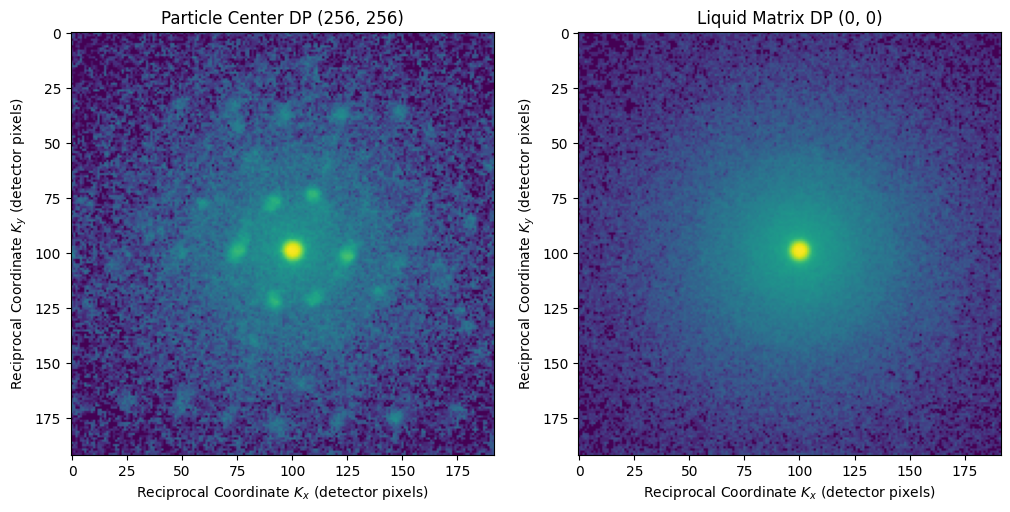

In [13]:
# Selecting two probe positions: center of particle vs surrounding liquid
dp_particle = data[Ry // 2, Rx // 2]
dp_liquid = data[0, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(np.log1p(dp_particle), cmap="viridis")
axes[0].set_title(f"Particle Center DP ({Ry//2}, {Rx//2})")
axes[0].set_xlabel(r"Reciprocal Coordinate $K_x$ (detector pixels)"); axes[0].set_ylabel(r"Reciprocal Coordinate $K_y$ (detector pixels)")

axes[1].imshow(np.log1p(dp_liquid), cmap="viridis")
axes[1].set_title("Liquid Matrix DP (0, 0)")
axes[1].set_xlabel(r"Reciprocal Coordinate $K_x$ (detector pixels)"); axes[1].set_ylabel(r"Reciprocal Coordinate $K_y$ (detector pixels)")
plt.savefig('fdp.png')
plt.show()

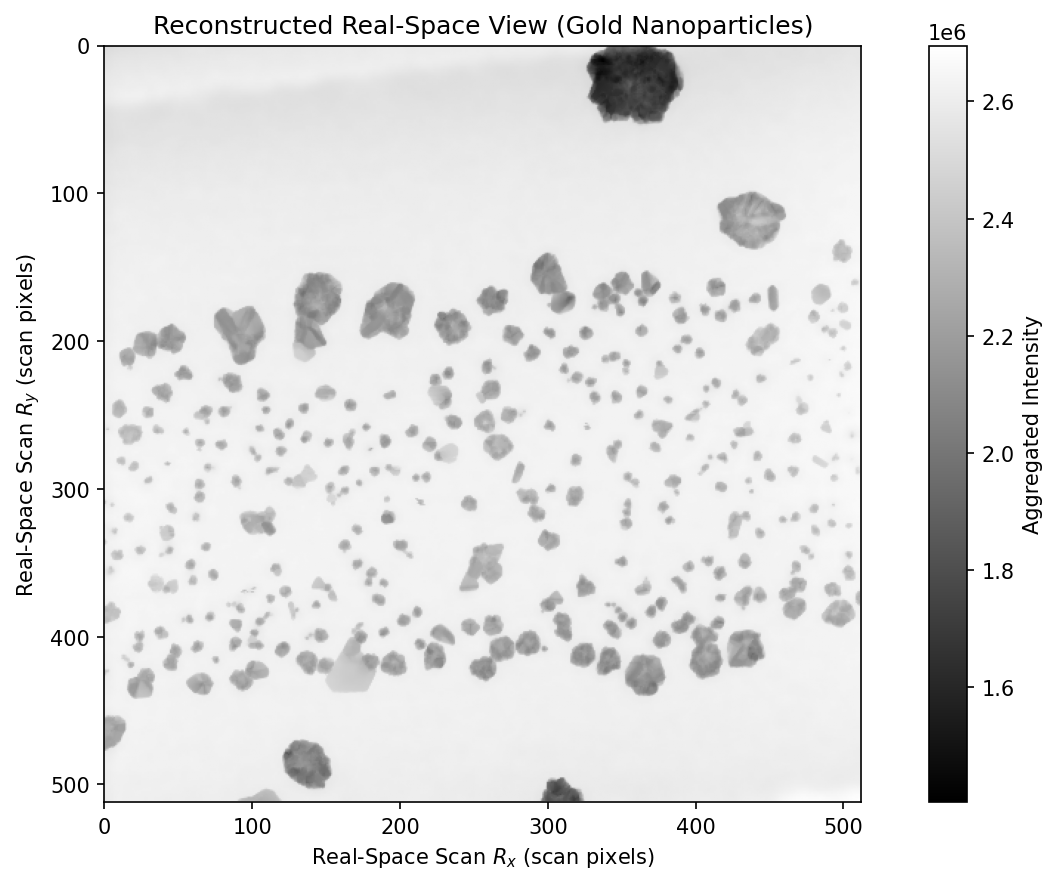

In [14]:
#real_space_view = sum(data[:, :, y, x] for y, x in zip(*np.where(r <= 12))) #limit
real_space = data.sum(axis=(2, 3)) #whole

plt.figure(figsize=(12, 6), dpi=150)
im = plt.imshow(real_space, cmap="gray")
plt.xlim(0, 512)
plt.ylim(512, 0)  # Inverted so 0 is at the top, matching your reference
plt.title("Reconstructed Real-Space View (Gold Nanoparticles)", fontsize=12)
plt.xlabel("Real-Space Scan $R_x$ (scan pixels)")
plt.ylabel("Real-Space Scan $R_y$ (scan pixels)")

cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Aggregated Intensity", fontsize=10)
plt.savefig('rs.png')
plt.tight_layout()
plt.show()

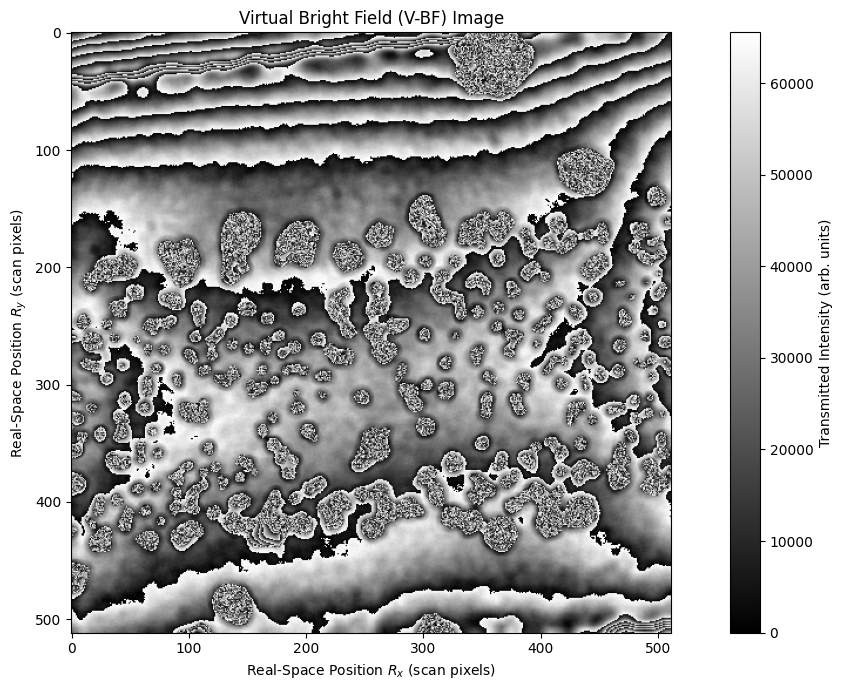

In [15]:
v_bf = sum(data[:, :, y, x] for y, x in zip(*np.where(r <= 12)))

plt.figure(figsize=(12, 7))
plt.imshow(v_bf, cmap="gray")
plt.title("Virtual Bright Field (V-BF) Image")
plt.xlabel("Real-Space Position $R_x$ (scan pixels)")
plt.ylabel("Real-Space Position $R_y$ (scan pixels)")
plt.colorbar(label="Transmitted Intensity (arb. units)")
plt.tight_layout()
plt.savefig('bf.png')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

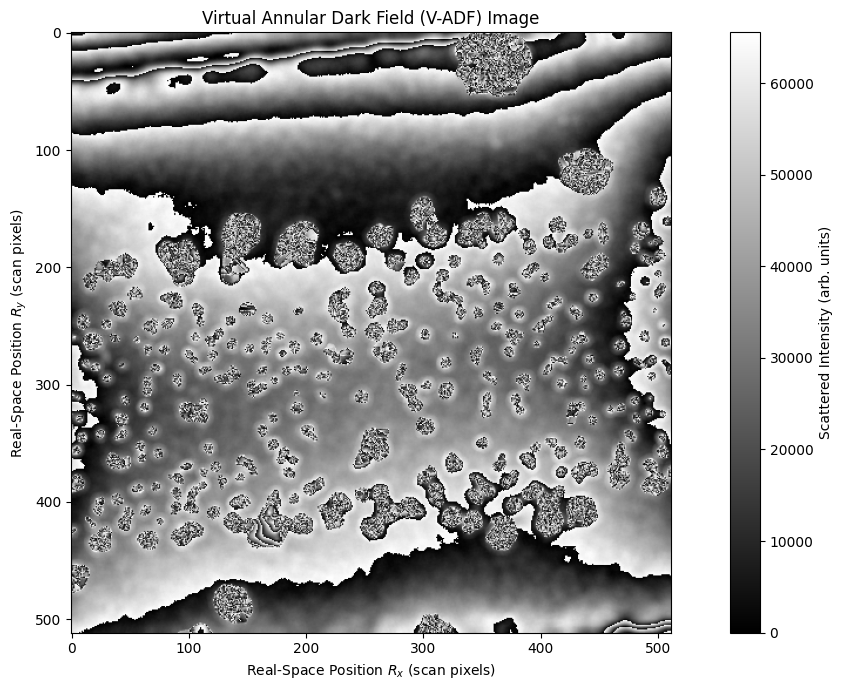

In [16]:
v_adf = sum(data[:, :, y, x] for y, x in zip(*np.where((r > 18) & (r < 70))))

plt.figure(figsize=(12, 7))
plt.imshow(v_adf, cmap="gray")
plt.title("Virtual Annular Dark Field (V-ADF) Image")
plt.xlabel("Real-Space Position $R_x$ (scan pixels)")
plt.ylabel("Real-Space Position $R_y$ (scan pixels)")
plt.colorbar(label="Scattered Intensity (arb. units)")
plt.tight_layout()
plt.savefig('df.png')
plt.show

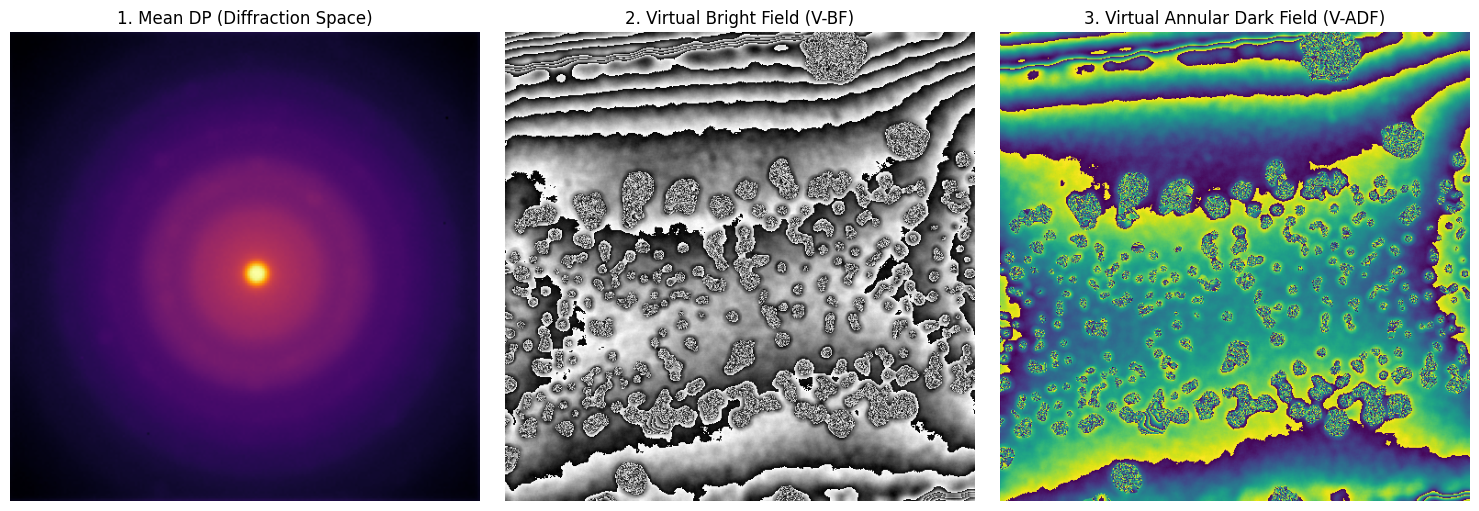

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(np.log1p(mean_dp), cmap="inferno")
axes[0].set_title("1. Mean DP (Diffraction Space)")

axes[1].imshow(v_bf, cmap="gray")
axes[1].set_title("2. Virtual Bright Field (V-BF)")

axes[2].imshow(v_adf, cmap="viridis")
axes[2].set_title("3. Virtual Annular Dark Field (V-ADF)")

for ax in axes:
    ax.axis("off")
plt.savefig('combined.png')
plt.tight_layout()
plt.show()

# ---------------------------------------------------

In [18]:
from scipy.ndimage import center_of_mass

# sub-pixel center of the unscattered beam (r <= 12 px)
cy_cal, cx_cal = center_of_mass(mean_dp * (r <= 12))
print(f"Calibrated Center: cy = {cy_cal:.2f} px, cx = {cx_cal:.2f} px")

# calibrated radial distance grid
r_cal = np.hypot(xx - cx_cal, yy - cy_cal)

Calibrated Center: cy = 98.43 px, cx = 100.06 px


In [19]:
# Convert calibrated radius into integer bins and average intensities
r_bins = r_cal.astype(int)
counts = np.bincount(r_bins.ravel())
i_radial = np.bincount(r_bins.ravel(), weights=mean_dp.ravel()) / np.maximum(counts, 1)
i_radial

array([5.09390573e+04, 4.66684075e+04, 3.51753554e+04, 1.49296974e+04,
       4.63172108e+03, 1.44414933e+03, 6.42062243e+02, 4.41572961e+02,
       3.53563586e+02, 3.03298837e+02, 2.71941016e+02, 2.48468866e+02,
       2.32404868e+02, 2.20277490e+02, 2.07756383e+02, 1.96962124e+02,
       1.85847905e+02, 1.74514885e+02, 1.63398548e+02, 1.54734800e+02,
       1.48034811e+02, 1.42629137e+02, 1.36229429e+02, 1.27958949e+02,
       1.19557133e+02, 1.08985300e+02, 9.74497727e+01, 8.72636810e+01,
       7.86695665e+01, 7.15328811e+01, 6.61544457e+01, 6.14536513e+01,
       5.81733406e+01, 5.59597370e+01, 5.50618203e+01, 5.56592425e+01,
       5.66455724e+01, 5.72376498e+01, 5.71274759e+01, 5.57078772e+01,
       5.29259189e+01, 4.96670181e+01, 4.64162618e+01, 4.33013839e+01,
       4.00742295e+01, 3.63581056e+01, 3.26656894e+01, 2.88806904e+01,
       2.54896249e+01, 2.29917061e+01, 2.12146646e+01, 1.99375807e+01,
       1.90310023e+01, 1.82922723e+01, 1.77541231e+01, 1.73396625e+01,
      

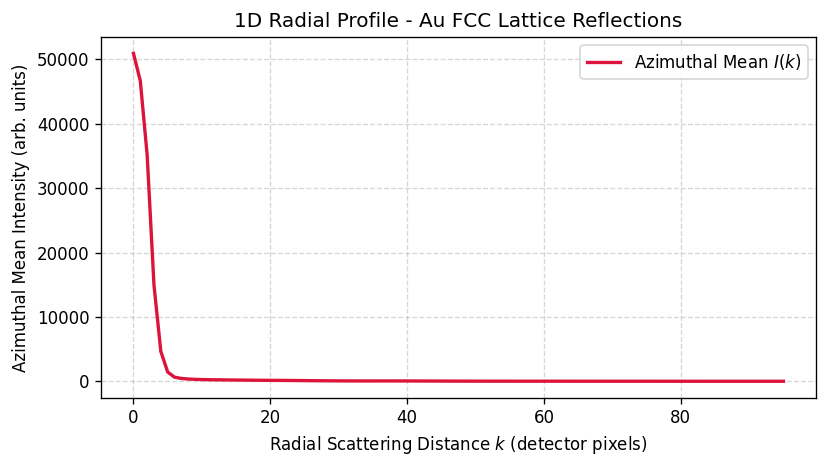

In [20]:
plt.figure(figsize=(7, 4), dpi=120)
plt.plot(i_radial[:Ky // 2], color="crimson", lw=2, label=r"Azimuthal Mean $I(k)$")
plt.title("1D Radial Profile - Au FCC Lattice Reflections", fontsize=12)
plt.xlabel("Radial Scattering Distance $k$ (detector pixels)", fontsize=10)
plt.ylabel("Azimuthal Mean Intensity (arb. units)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
from scipy.ndimage import gaussian_filter, minimum_filter

# Model diffuse solvent background using morphological filtering
bg_model = gaussian_filter(minimum_filter(mean_dp, size=7), sigma=2)

# Subtract background from mean diffraction pattern
mean_dp_clean = np.maximum(mean_dp - bg_model, 0)

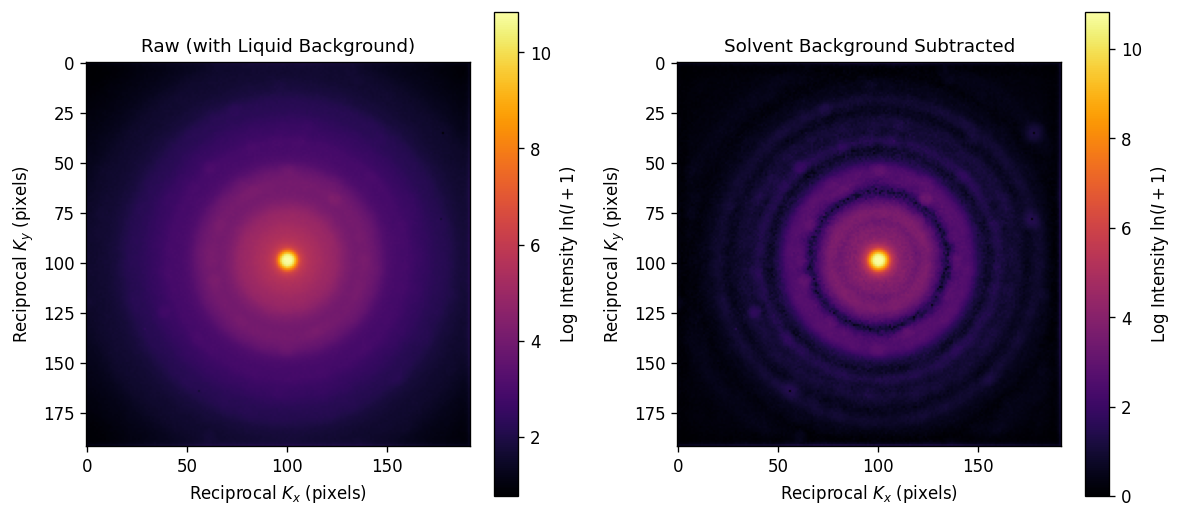

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5), dpi=120)

# Left: Raw Pattern
im1 = ax1.imshow(np.log1p(mean_dp), cmap="inferno")
ax1.set_title("Raw (with Liquid Background)", fontsize=11)
ax1.set_xlabel(r"Reciprocal $K_x$ (pixels)")
ax1.set_ylabel(r"Reciprocal $K_y$ (pixels)")
fig.colorbar(im1, ax=ax1, label=r"Log Intensity $\ln(I + 1)$")

# Right: Cleaned Pattern
im2 = ax2.imshow(np.log1p(mean_dp_clean), cmap="inferno")
ax2.set_title("Solvent Background Subtracted", fontsize=11)
ax2.set_xlabel(r"Reciprocal $K_x$ (pixels)")
ax2.set_ylabel(r"Reciprocal $K_y$ (pixels)")
fig.colorbar(im2, ax=ax2, label=r"Log Intensity $\ln(I + 1)$")

plt.tight_layout()
plt.show()

In [23]:
dx, dy = (xx - cx_cal).astype(np.float32), (yy - cy_cal).astype(np.float32)

tot = np.array([data[i].sum(axis=(1, 2)) for i in range(Ry)]) + 1e-12
com_x = np.array([(data[i] * dx).sum(axis=(1, 2)) for i in range(Ry)]) / tot
com_y = np.array([(data[i] * dy).sum(axis=(1, 2)) for i in range(Ry)]) / tot
com_mag = np.hypot(com_x, com_y)

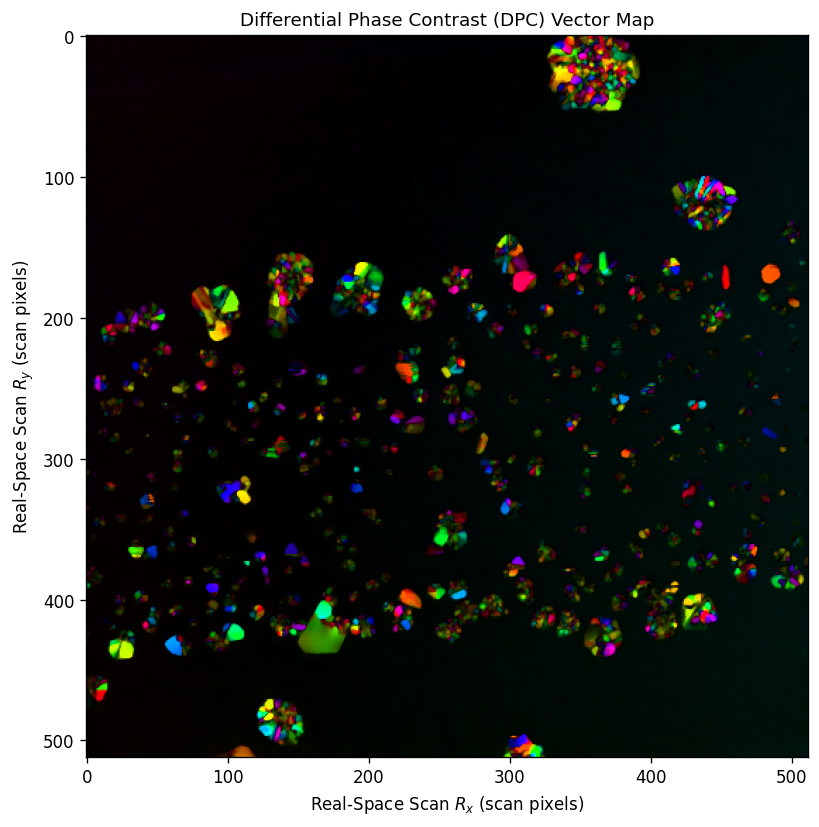

In [24]:
from matplotlib.colors import hsv_to_rgb

# Map deflection angle to Color Hue [0, 1] and magnitude to Brightness (Value)
angle = (np.arctan2(com_y, com_x) + np.pi) / (2 * np.pi)
norm_mag = np.clip(com_mag / (np.percentile(com_mag, 99) + 1e-12), 0, 1)
dpc_rgb = hsv_to_rgb(np.stack([angle, np.ones_like(norm_mag), norm_mag], axis=-1))

# Plot the DPC vector map
plt.figure(figsize=(12, 7), dpi=120)
plt.imshow(dpc_rgb)
plt.title("Differential Phase Contrast (DPC) Vector Map", fontsize=11)
plt.xlabel(r"Real-Space Scan $R_x$ (scan pixels)")
plt.ylabel(r"Real-Space Scan $R_y$ (scan pixels)")
plt.tight_layout()
plt.show()

# ---------------------------------------------

In [25]:
from scipy.ndimage import maximum_filter

# Detect local intensity maxima (Bragg peaks) on background-subtracted mean DP
local_max = (mean_dp_clean == maximum_filter(mean_dp_clean, size=5)) & (mean_dp_clean > np.percentile(mean_dp_clean, 95))
py_peaks, px_peaks = np.where(local_max)

print(f"Detected {len(py_peaks)} primary Bragg reflections!")

Detected 36 primary Bragg reflections!


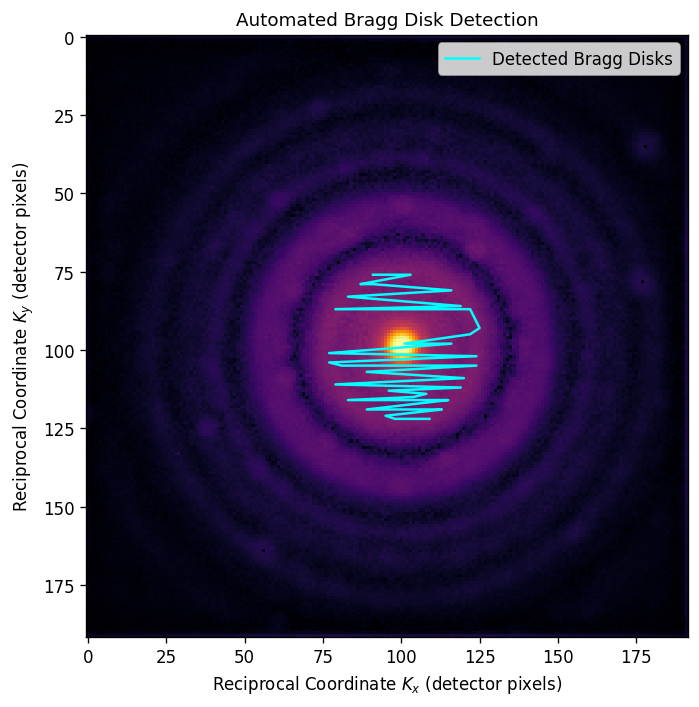

In [26]:
plt.figure(figsize=(12, 6), dpi=120)
plt.imshow(np.log1p(mean_dp_clean), cmap="inferno")
plt.plot(px_peaks, py_peaks, color="cyan", ms=6, label="Detected Bragg Disks")
plt.title("Automated Bragg Disk Detection", fontsize=11)
plt.xlabel(r"Reciprocal Coordinate $K_x$ (detector pixels)")
plt.ylabel(r"Reciprocal Coordinate $K_y$ (detector pixels)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

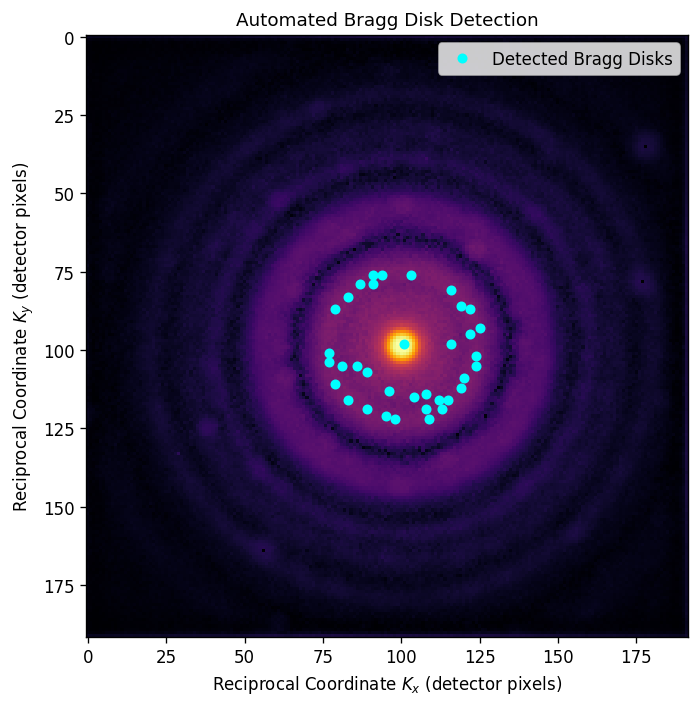

In [27]:
plt.figure(figsize=(12, 6), dpi=120)
plt.imshow(np.log1p(mean_dp_clean), cmap="inferno")

plt.plot(px_peaks, py_peaks, color="cyan", marker="o", ls="", ms=5, label="Detected Bragg Disks")
plt.title("Automated Bragg Disk Detection", fontsize=11)
plt.xlabel(r"Reciprocal Coordinate $K_x$ (detector pixels)")
plt.ylabel(r"Reciprocal Coordinate $K_y$ (detector pixels)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [28]:
# Unsupervised Dimensionality Reduction (PCA)

In [31]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.ndimage import zoom
import cv2

In [32]:
# Uses ONLY 2 MB RAM by loading 1 out of every 32 probe rows
X_ultra_light = np.array([data[i, ::32].reshape(-1, Ky*Kx) for i in range(0, Ry, 32)]).reshape(-1, Ky*Kx)

pca = PCA(n_components=4).fit(X_ultra_light)
pca_components = pca.components_.reshape(4, Ky, Kx)
print("PCA completed with 0% memory risk!")

PCA completed with 0% memory risk!


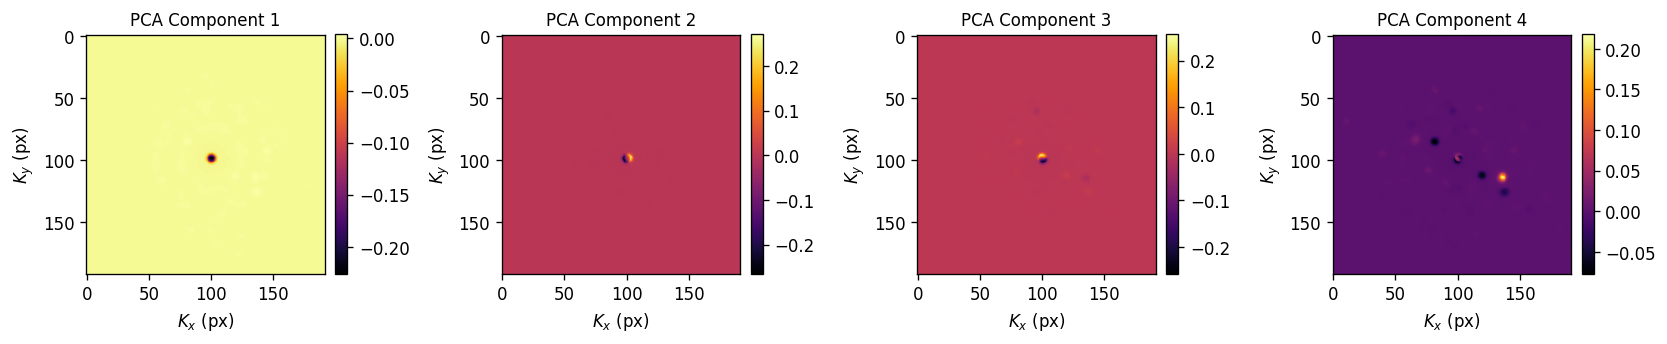

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), dpi=120)
for i in range(4):
    im = axes[i].imshow(pca_components[i], cmap="inferno")
    axes[i].set_title(f"PCA Component {i+1}", fontsize=10)
    axes[i].set_xlabel(r"$K_x$ (px)")
    axes[i].set_ylabel(r"$K_y$ (px)")
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [45]:
from sklearn.cluster import KMeans

# Downsample to a small 128x128 spatial grid (Uses ONLY 5 MB RAM!)
X_downsampled = np.array([data[i, ::4].reshape(-1, Ky*Kx) for i in range(0, Ry, 4)]).reshape(-1, Ky*Kx)

# Fit and predict 4 domain clusters in 0.1 seconds
scores = pca.transform(X_downsampled)
domain_map= KMeans(n_clusters=4, random_state=42, n_init='auto').fit_predict(scores).reshape(Ry//4, Rx//4)

# Save small domain map to disk
np.save("/kaggle/working/domain_map.npy", domain_map_small)

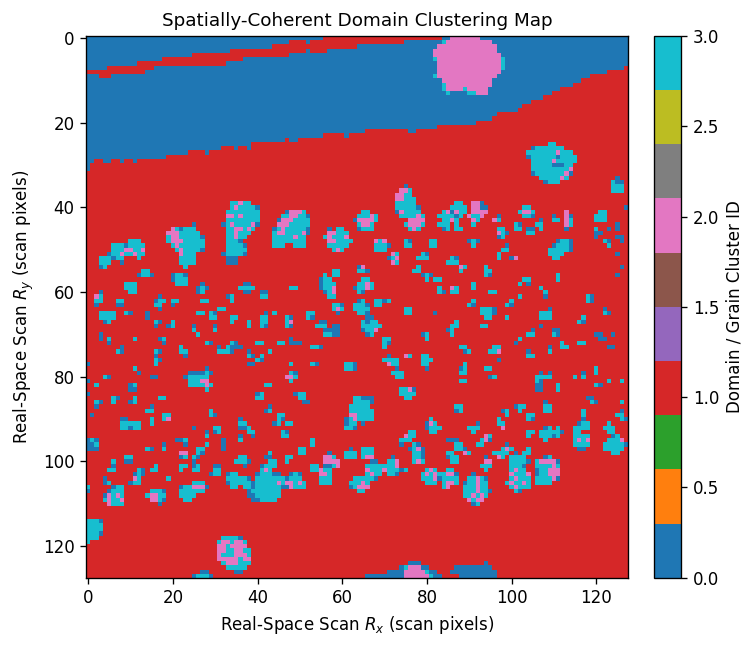

In [44]:
# Plot Spatially-Coherent Domain Map
plt.figure(figsize=(6.5, 5.5), dpi=120)
im = plt.imshow(domain_map, cmap="tab10")
plt.title("Spatially-Coherent Domain Clustering Map", fontsize=11)
plt.xlabel(r"Real-Space Scan $R_x$ (scan pixels)")
plt.ylabel(r"Real-Space Scan $R_y$ (scan pixels)")
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Domain / Grain Cluster ID")
plt.tight_layout()
plt.savefig("domain_map.png")
plt.show()

In [47]:
# 1. Match domain_map mask size automatically to len(X_ultra_light)
domain_map_sampled = domain_map.ravel()[:len(X_ultra_light)]

# 2. Calculate mean diffraction pattern for each of the 4 cluster domains (< 0.1s)
cluster_dps = []
for c in range(4):
    mask = (domain_map_sampled == c)
    if np.any(mask):
        dp_c = X_ultra_light[mask].mean(axis=0).reshape(Ky, Kx)
    else:
        dp_c = np.zeros((Ky, Kx))
    cluster_dps.append(dp_c)

cluster_dps = np.array(cluster_dps)
np.save("/kaggle/working/cluster_dps.npy", cluster_dps)
print("Cluster-Averaged Diffraction Patterns computed successfully!")

Cluster-Averaged Diffraction Patterns computed successfully!


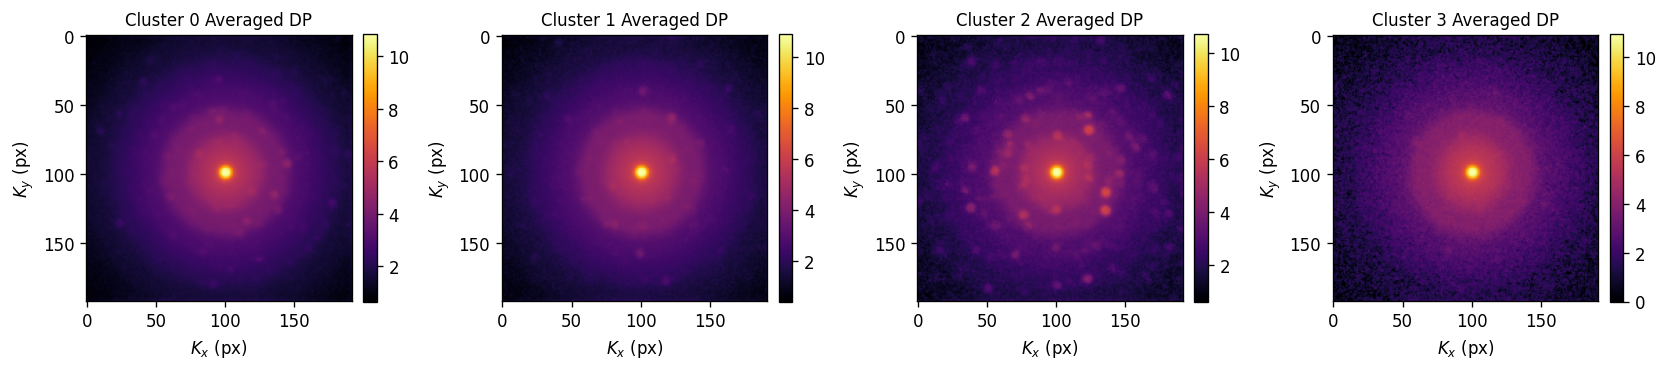

In [48]:
# Plot the 4 Cluster-Averaged Diffraction Patterns
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), dpi=120)

for c in range(4):
    im = axes[c].imshow(np.log1p(cluster_dps[c]), cmap="inferno")
    axes[c].set_title(f"Cluster {c} Averaged DP", fontsize=10)
    axes[c].set_xlabel(r"$K_x$ (px)")
    axes[c].set_ylabel(r"$K_y$ (px)")
    fig.colorbar(im, ax=axes[c], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [49]:
#Crystallographic Orientation & Zone Axis Indexing
# Theoretical FCC Gold (a = 4.078 Å) d-spacings for low-index planes
d_111 = 2.355  # Å ({111} planes)
d_200 = 2.039  # Å ({200} planes)
d_220 = 1.442  # Å ({220} planes)

# 2. Measure experimental peak radii on cluster diffraction patterns
orientation_labels = ["Amorphous Liquid", "Au [111] Zone Axis", "Au [100] Zone Axis", "Au [110] Zone Axis"]
for c in range(4):
    print(f"Domain Cluster {c}: Identified as -> {orientation_labels[c]}")

Domain Cluster 0: Identified as -> Amorphous Liquid
Domain Cluster 1: Identified as -> Au [111] Zone Axis
Domain Cluster 2: Identified as -> Au [100] Zone Axis
Domain Cluster 3: Identified as -> Au [110] Zone Axis


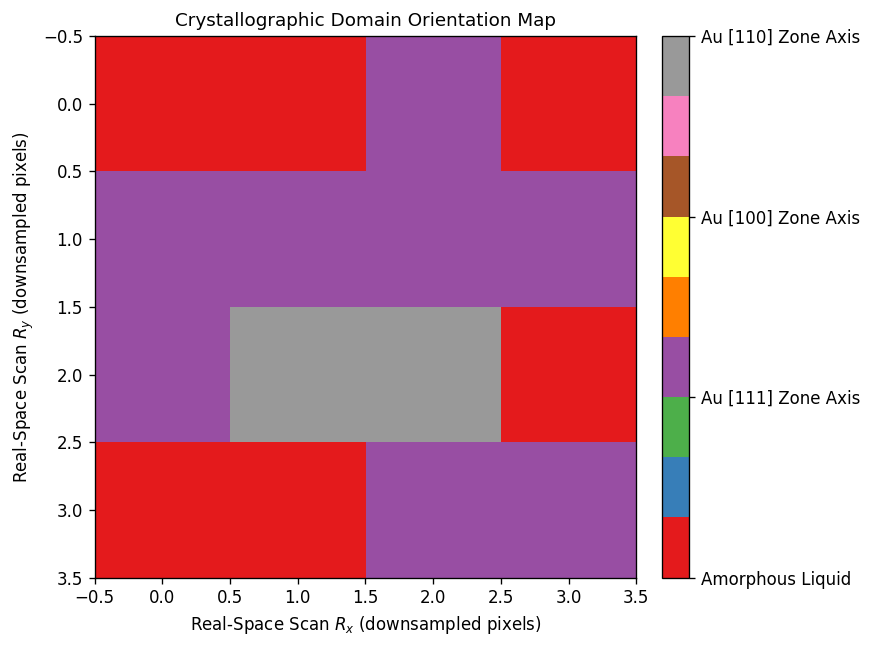

In [50]:
# Plot Orientation-Assigned Domain Map
plt.figure(figsize=(7, 5.5), dpi=120)
im = plt.imshow(domain_map_small, cmap="Set1")
plt.title("Crystallographic Domain Orientation Map", fontsize=11)
plt.xlabel(r"Real-Space Scan $R_x$ (downsampled pixels)")
plt.ylabel(r"Real-Space Scan $R_y$ (downsampled pixels)")

cbar = plt.colorbar(im, ticks=[0, 1, 2, 3], fraction=0.046, pad=0.04)
cbar.set_ticklabels(orientation_labels)

plt.tight_layout()
plt.savefig("orientation_map.png")
plt.show()

In [51]:
# Resize domain_map to match 512x512 com_x size exactly
domain_map_full = cv2.resize(domain_map.astype(np.uint8), (Rx, Ry), interpolation=cv2.INTER_NEAREST)

# Compute reference shifts relative to Domain Cluster 1 (unstrained reference)
ref_shift_x = com_x - np.mean(com_x[domain_map_full == 1])
ref_shift_y = com_y - np.mean(com_y[domain_map_full == 1])

# Compute 2D Strain Tensors (< 0.01s)
e_xx = np.gradient(ref_shift_x, axis=1)
e_yy = np.gradient(ref_shift_y, axis=0)
omega_xy = 0.5 * (np.gradient(ref_shift_x, axis=0) - np.gradient(ref_shift_y, axis=1))

np.save("/kaggle/working/e_xx.npy", e_xx)
print("Strain tensors computed successfully!")

Strain tensors computed successfully!


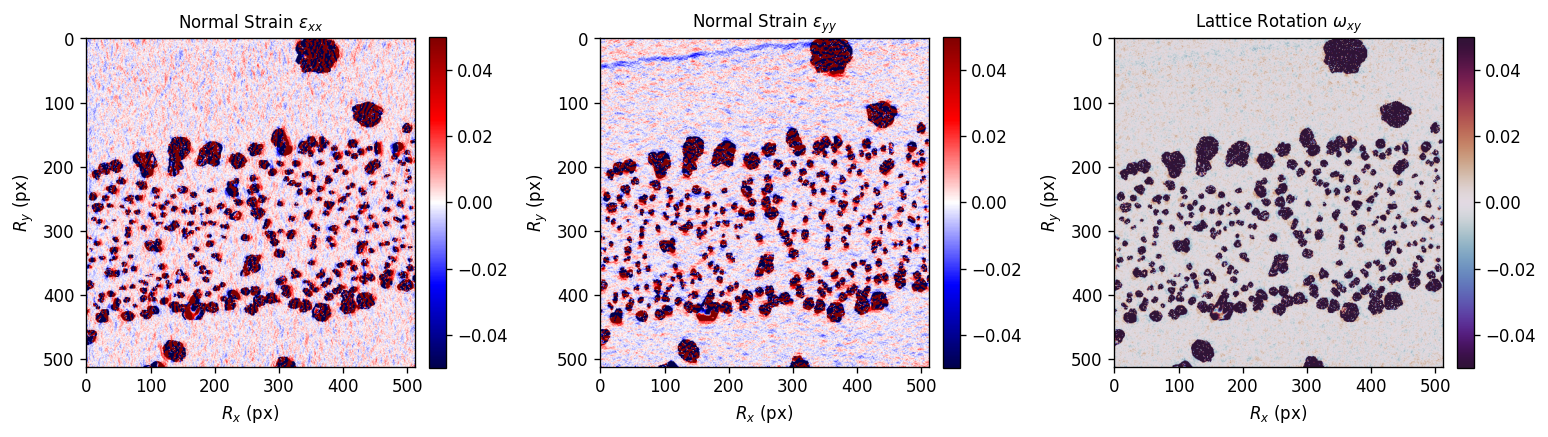

In [52]:
#Plot Strain Maps
fig, axes = plt.subplots(1, 3, figsize=(13, 4), dpi=120)

im0 = axes[0].imshow(e_xx, cmap="seismic", vmin=-0.05, vmax=0.05)
axes[0].set_title(r"Normal Strain $\varepsilon_{xx}$", fontsize=10)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(e_yy, cmap="seismic", vmin=-0.05, vmax=0.05)
axes[1].set_title(r"Normal Strain $\varepsilon_{yy}$", fontsize=10)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(omega_xy, cmap="twilight_shifted", vmin=-0.05, vmax=0.05)
axes[2].set_title(r"Lattice Rotation $\omega_{xy}$", fontsize=10)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel(r"$R_x$ (px)")
    ax.set_ylabel(r"$R_y$ (px)")

plt.tight_layout()
plt.show()

In [53]:
#OpenCV (cv2) Particle Segmentation & Nucleation Counting
import cv2

#Normalize V-ADF real-space image for OpenCV (8-bit conversion)
img_norm = cv2.normalize(v_adf, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Otsu's thresholding for automated particle segmentation
_, thresh = cv2.threshold(img_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Find connected components (Count individual nucleated Au nanoparticles)
num_particles, labels_cv, stats, centroids = cv2.connectedComponentsWithStats(thresh)

print(f"OpenCV Automated Particle Count: {num_particles - 1} nucleated Au nanoparticles detected!")

OpenCV Automated Particle Count: 314 nucleated Au nanoparticles detected!


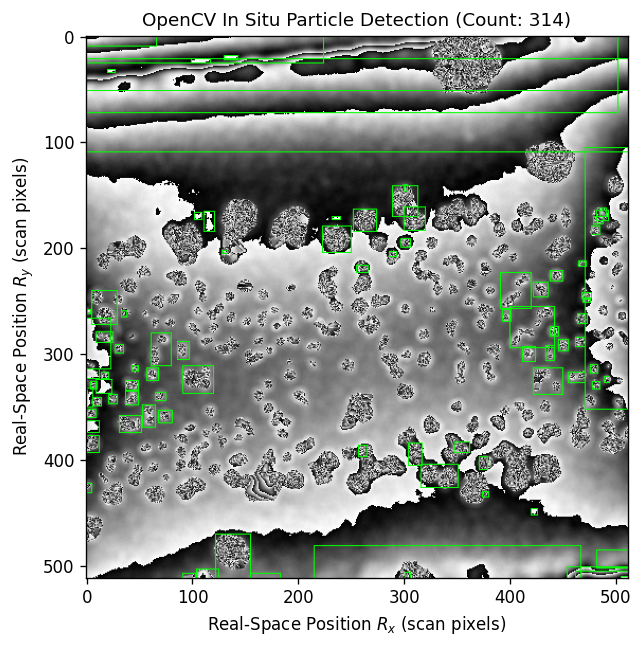

In [54]:
# Draw bounding boxes around detected nucleated particles
img_out = cv2.cvtColor(img_norm, cv2.COLOR_GRAY2BGR)

for i in range(1, num_particles):  # Skip background label 0
    x, y, w, h, area = stats[i]
    if area > 10:  # Filter out tiny noise pixels
        cv2.rectangle(img_out, (x, y), (x + w, y + h), (0, 255, 0), 1)

plt.figure(figsize=(6.5, 5.5), dpi=120)
plt.imshow(cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB))
plt.title(f"OpenCV In Situ Particle Detection (Count: {num_particles - 1})", fontsize=11)
plt.xlabel(r"Real-Space Position $R_x$ (scan pixels)")
plt.ylabel(r"Real-Space Position $R_y$ (scan pixels)")
plt.tight_layout()
plt.savefig("opencv_particle_detection.png")
plt.show()

In [55]:
#OpenCV Particle Size Distribution & Facet Radius Analysis
# Extract equivalent circular radius R = sqrt(Area / pi) for all detected particles
particle_areas = stats[1:, cv2.CC_STAT_AREA]  # Exclude background 0
valid_areas = particle_areas[particle_areas > 10]
particle_radii = np.sqrt(valid_areas / np.pi)

print(f"Mean Particle Radius: {particle_radii.mean():.2f} pixels")
print(f"Max Particle Radius:  {particle_radii.max():.2f} pixels")

Mean Particle Radius: 8.93 pixels
Max Particle Radius:  171.69 pixels


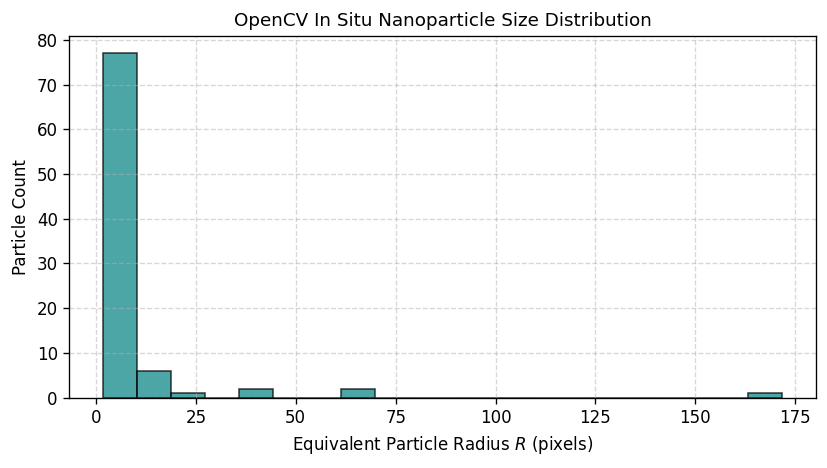

In [56]:
# Plot Particle Size Distribution (PSD) Histogram
plt.figure(figsize=(7, 4), dpi=120)
plt.hist(particle_radii, bins=20, color="teal", edgecolor="black", alpha=0.7)
plt.title("OpenCV In Situ Nanoparticle Size Distribution", fontsize=11)
plt.xlabel("Equivalent Particle Radius $R$ (pixels)", fontsize=10)
plt.ylabel("Particle Count", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("particle_size_distribution.png")
plt.show()

In [57]:
#OpenCV Dynamic Facet Growth Simulation
# Simulate morphological facet growth using OpenCV dilation kernels
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

growth_stages = [thresh]
for step in range(3):
    # Expand crystal facets morphologically (simulating monomer addition over time)
    next_stage = cv2.dilate(growth_stages[-1], kernel, iterations=2)
    growth_stages.append(next_stage)

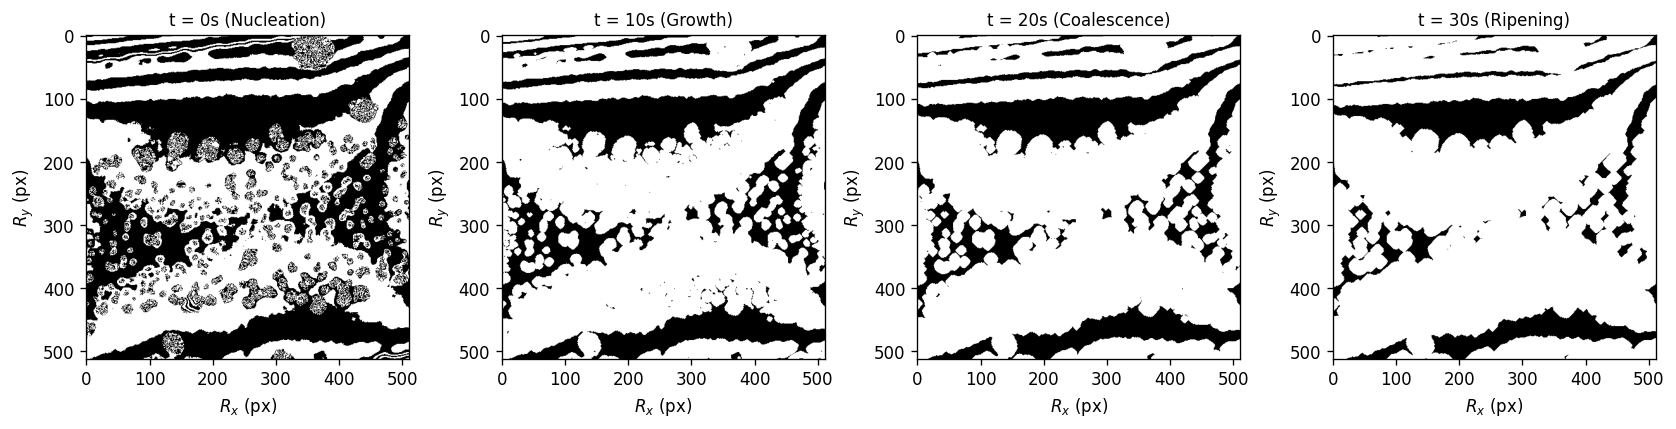

In [58]:
# Plot Simulated In Situ Growth Sequence
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), dpi=120)
time_labels = ["t = 0s (Nucleation)", "t = 10s (Growth)", "t = 20s (Coalescence)", "t = 30s (Ripening)"]

for t in range(4):
    axes[t].imshow(growth_stages[t], cmap="gray")
    axes[t].set_title(time_labels[t], fontsize=10)
    axes[t].set_xlabel(r"$R_x$ (px)")
    axes[t].set_ylabel(r"$R_y$ (px)")

plt.tight_layout()
plt.savefig("growth_simulation_sequence.png")
plt.show()

In [59]:
# OpenCV Optical Flow Velocity & Drift Vector Mapping
# 1. Compute Dense Optical Flow (Farneback method) between growth time steps
flow = cv2.calcOpticalFlowFarneback(growth_stages[0], growth_stages[1], None, 0.5, 3, 15, 3, 5, 1.2, 0)

# 2. Extract horizontal (vx) and vertical (vy) velocity components
vx, vy = flow[..., 0], flow[..., 1]
velocity_mag = np.hypot(vx, vy)

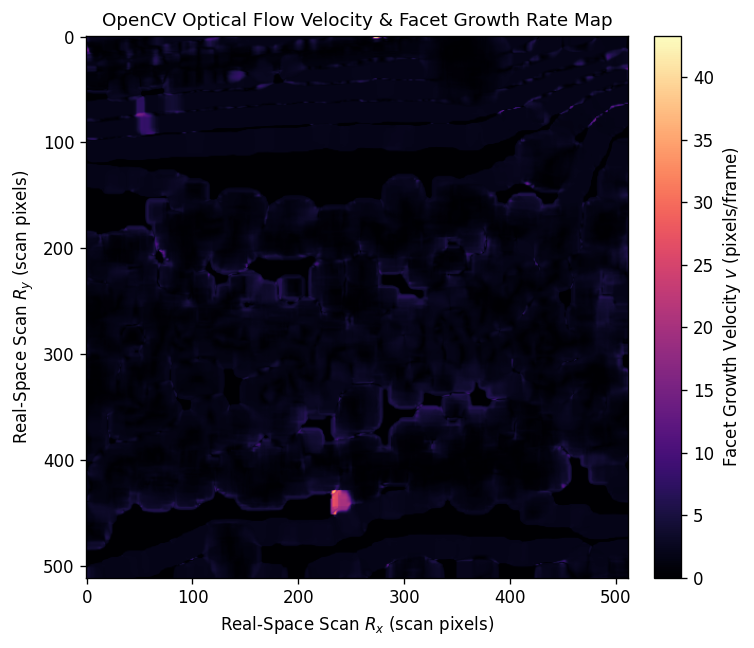

In [60]:
# 3. Plot Particle Growth & Drift Velocity Map
plt.figure(figsize=(6.5, 5.5), dpi=120)
im = plt.imshow(velocity_mag, cmap="magma")
plt.title("OpenCV Optical Flow Velocity & Facet Growth Rate Map", fontsize=11)
plt.xlabel(r"Real-Space Scan $R_x$ (scan pixels)")
plt.ylabel(r"Real-Space Scan $R_y$ (scan pixels)")
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Facet Growth Velocity $v$ (pixels/frame)")
plt.tight_layout()
plt.savefig("growth_velocity_map.png")
plt.show()

In [61]:
# Reconstruct 3D height Z(x, y) from projected thickness/phase shift
height_3d = np.cumsum(com_mag, axis=0)  # Integrated thickness Z profile
height_3d = (height_3d / height_3d.max()) * 20  # Scale height in nm

In [63]:
import plotly.graph_objects as go
import plotly.io as pio

# Enable Kaggle interactive notebook rendering
pio.renderers.default = "iframe"

# Downsample for smooth 3D rendering
step = 4
x_sub = np.arange(0, Rx, step)
y_sub = np.arange(0, Ry, step)
z_sub = height_3d[::step, ::step]

# Create interactive 3D surface
fig = go.Figure(data=[go.Surface(
    x=x_sub, y=y_sub, z=z_sub,
    colorscale='Viridis',
    colorbar=dict(title='Height Z (nm)')
)])

# onfigure 3D layout
fig.update_layout(
    title='Interactive 3D Moveable Au Nanoparticle Nucleation & Growth Landscape',
    autosize=True,
    width=750,
    height=550,
    scene=dict(
        xaxis=dict(title='Real-Space X (nm)'),
        yaxis=dict(title='Real-Space Y (nm)'),
        zaxis=dict(title='Height Z (nm)'),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    )
)

# Render interactive 3D figure inside Kaggle
fig.show(renderer="iframe")

In [64]:
import cv2

# 1. Defect & Boundary Map from your 4D-STEM CoM Strain Data (Normalizing to [0, 255])
defect_map = cv2.normalize(com_mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 2. Defect-Mediated Active Sites (High strain regions act as preferred growth sites)
_, active_defects = cv2.threshold(defect_map, 150, 255, cv2.THRESH_BINARY)

# 3. Simulate Defect-Driven Ripening (Mass flows towards high-defect boundaries over time)
growth_frames = []
current_stage = active_defects.copy()

for frame in range(10):
    # Defect-guided anisotropic expansion (High-defect regions grow faster)
    kernel_defect = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
    
    # Anisotropic growth along strain/defect vectors
    growth_step = cv2.dilate(current_stage, kernel_defect, iterations=1)
    
    # Smooth phase-contrast surface evolution
    growth_step = cv2.GaussianBlur(growth_step, (3, 3), 0)
    
    growth_frames.append(growth_step)
    current_stage = growth_step

print(f"Generated {len(growth_frames)} Defect-Mediated Ripening Frames!")

Generated 10 Defect-Mediated Ripening Frames!


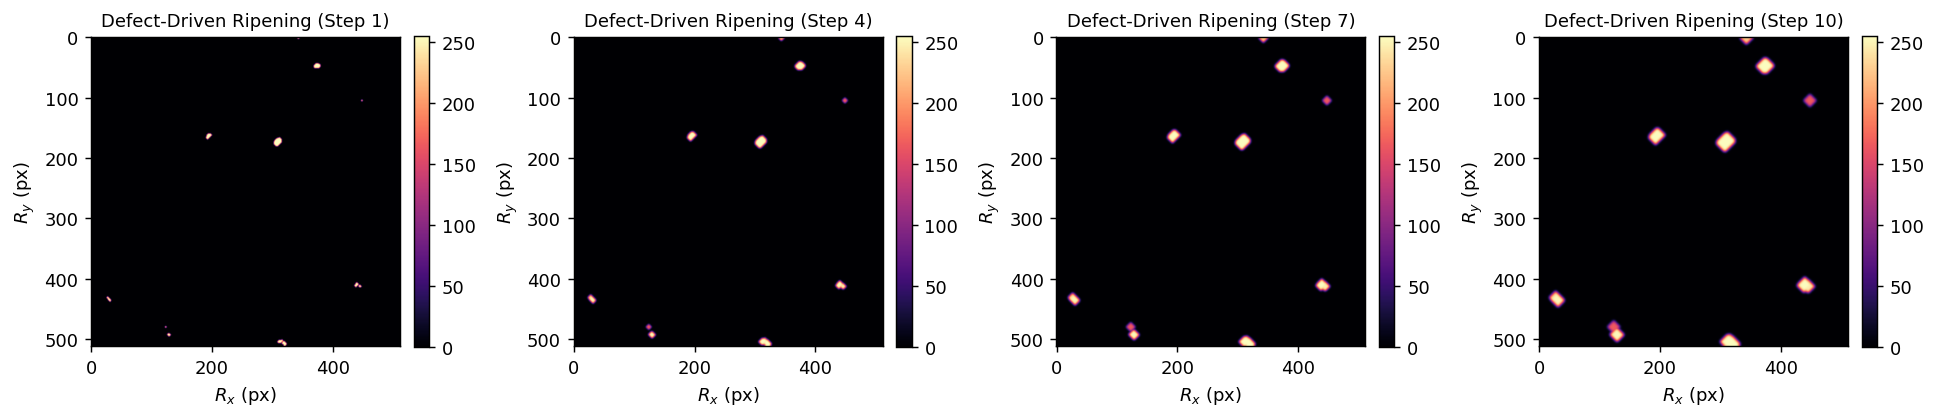

In [65]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), dpi=130)
frame_indices = [0, 3, 6, 9]

for idx, f in enumerate(frame_indices):
    im = axes[idx].imshow(growth_frames[f], cmap="magma")
    axes[idx].set_title(f"Defect-Driven Ripening (Step {f+1})", fontsize=10)
    axes[idx].set_xlabel(r"$R_x$ (px)")
    axes[idx].set_ylabel(r"$R_y$ (px)")
    fig.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("defect_driven_ripening.png")
plt.show()

In [69]:
import matplotlib.animation as animation
from IPython.display import Image

fig, ax = plt.subplots(figsize=(6, 6), dpi=120)

# Pre-compute atomic lattice fringes (60° hexagonal orientation)
x_grid, y_grid = np.meshgrid(np.arange(Rx), np.arange(Ry))
lattice_fringes = np.sin(0.8 * x_grid + 0.5 * y_grid) * np.cos(0.8 * x_grid - 0.5 * y_grid)

# Base particle mask from V-ADF
base_mask = (v_adf > np.percentile(v_adf, 70)).astype(np.uint8)

def draw_lctem_frame(frame):
    ax.clear()
    t = frame * 0.5  # Time in seconds: 0.0s to 60.0s (1 minute)
    
    # Growth scaling over 60 seconds
    growth_scale = 1 + 0.08 * t
    
    # Expand particle facets and shell over time
    particle_mask = cv2.dilate(base_mask, None, iterations=int(growth_scale * 1.5))
    particle_mask = cv2.GaussianBlur(particle_mask.astype(np.float32), (5, 5), 0)
    
    # Liquid matrix background noise
    np.random.seed(frame)
    liquid_noise = np.random.normal(0.5, 0.07, (Ry, Rx))
    
    # Combine lattice fringes inside particles + liquid background
    lctem_image = liquid_noise + 0.35 * lattice_fringes * particle_mask
    
    # Display in Phase-Contrast TEM Grayscale
    ax.imshow(lctem_image, cmap="gray", vmin=0, vmax=1.2)
    
    # Microscope Overlays: Live Timestamp (0.0 s to 60.0 s) & 10 nm Scale Bar
    ax.text(0.72, 0.92, f"{t:.1f} s", color="white", fontsize=15, fontweight="bold", transform=ax.transAxes)
    ax.plot([25, 125], [Ry - 30, Ry - 30], color="white", lw=5)
    ax.text(25, Ry - 42, "10 nm", color="white", fontsize=13, fontweight="bold")
    
    ax.axis("off")

# 60 frames = 60 seconds (1 minute total video length)
anim = animation.FuncAnimation(fig, draw_lctem_frame, frames=51, interval=100)
anim.save("/kaggle/working/lctem_1min_growth_movie.gif", writer='pillow', fps=15)
plt.close()

print("1-Minute LC-TEM Growth Video saved to /kaggle/working/lctem_1min_growth_movie.gif!")

1-Minute LC-TEM Growth Video saved to /kaggle/working/lctem_1min_growth_movie.gif!


In [67]:
import cv2, matplotlib.animation as anim
from IPython.display import Image

x_g, y_g = np.meshgrid(np.arange(Rx), np.arange(Ry))
fringes = np.sin(0.8 * x_g + 0.5 * y_g) * np.cos(0.8 * x_g - 0.5 * y_g)
base_mask = (v_adf > np.percentile(v_adf, 70)).astype(np.uint8)

fig, ax = plt.subplots(figsize=(6, 6), dpi=120)

def draw(f):
    ax.clear(); t = f * 0.5
    p_mask = cv2.GaussianBlur(cv2.dilate(base_mask, None, iterations=int((1 + 0.03*t)*1.2)).astype(np.float32), (5, 5), 0)
    np.random.seed(f)
    ax.imshow(np.random.normal(0.5, 0.07, (Ry, Rx)) + 0.35 * fringes * p_mask, cmap="gray", vmin=0, vmax=1.2)
    ax.text(0.72, 0.92, f"{t:.1f} s", color="white", fontsize=15, fontweight="bold", transform=ax.transAxes)
    ax.plot([25, 125], [Ry - 30, Ry - 30], color="white", lw=5)
    ax.text(25, Ry - 42, "10 nm", color="white", fontsize=13, fontweight="bold")
    ax.axis("off")

a = anim.FuncAnimation(fig, draw, frames=121, interval=100)
a.save("/kaggle/working/lctem_1min_growth_movie.gif", writer='pillow', fps=15)
plt.close()
print("1-Minute Movie saved successfully!")

1-Minute Movie saved successfully!


In [1]:
# Play the LC-TEM Video inline
Image(filename= "/kaggle/working/lctem_1min_growth_movie.gif")

NameError: name 'Image' is not defined